In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Load enriched dataset
df = pd.read_csv('df_enriched.csv')

print(f"Loaded df_enriched.csv")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")

Loaded df_enriched.csv
  Shape   : (711168, 26)
  Columns : ['storeId', 'rating', 'lunchTime', 'sold', 'price', 'discount', 'shippingCost', 'storeUrl', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'free_shipping_flag', 'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg', 'store_avg_discount', 'sales_per_discount', 'is_ad', 'price_rank_in_category', 'discount_rank_in_category', 'total_cost', 'store_avg_sold', 'discount_tier']


#  Drop Non-ML Columns : 
>these columns are not useful for ML : storeUrl , lunchTime, discount_tier 

In [2]:
df = df.drop(columns=['storeUrl', 'lunchTime', 'discount_tier'], errors='ignore')
print(f" Dropped 3 columns")
print(f"   shape : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")

 Dropped 3 columns
   shape : (711168, 23)
  Columns : ['storeId', 'rating', 'sold', 'price', 'discount', 'shippingCost', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'free_shipping_flag', 'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg', 'store_avg_discount', 'sales_per_discount', 'is_ad', 'price_rank_in_category', 'discount_rank_in_category', 'total_cost', 'store_avg_sold']


# why?

**storeUrl**:

it's just an identifier
    ===The useful information it contained (store identity) was already captured by storeId
    
**lunchTime**:

 =datetime string of when the product was listed
 The temporal signal it contained was already extracted into:
 • listing_month  (Feature 5) = seasonality
 • listing_year   (Feature 5) = year-over-year trends
=== Keeping it is  redundant and wastes memory


**discount_tier** : 

The raw discount column + discount_rank_in_category (Feature 11) already carry this information in a richer, continuous form


# Define feature
that will be evaluated for selection 

In [3]:
features = [
    'rating', 'sold', 'price', 'discount', 'shippingCost',
    'effective_price', 'discount_aggressiveness', 'free_shipping_flag',
    'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg',
    'store_avg_discount', 'sales_per_discount', 'is_ad',
    'price_rank_in_category', 'discount_rank_in_category',
    'total_cost', 'store_avg_sold', 'category_id', 'storeId'
]

print(f" {len(features)} features to evaluate")

 21 features to evaluate


 # correlation Heatmap 


 **Goal**: detect redundant features before feeding them into the ML model.

 **Theory** (Pearson correlation):
 
   • r close to +1 → both features rise together (e.g. price & total_cost)
   
   • r close to -1 → one rises as the other falls
   
   • r close to  0 → no linear relationship

   
 **Decision rule used here**:
   |r| > 0.85 → features are redundant → keep only one


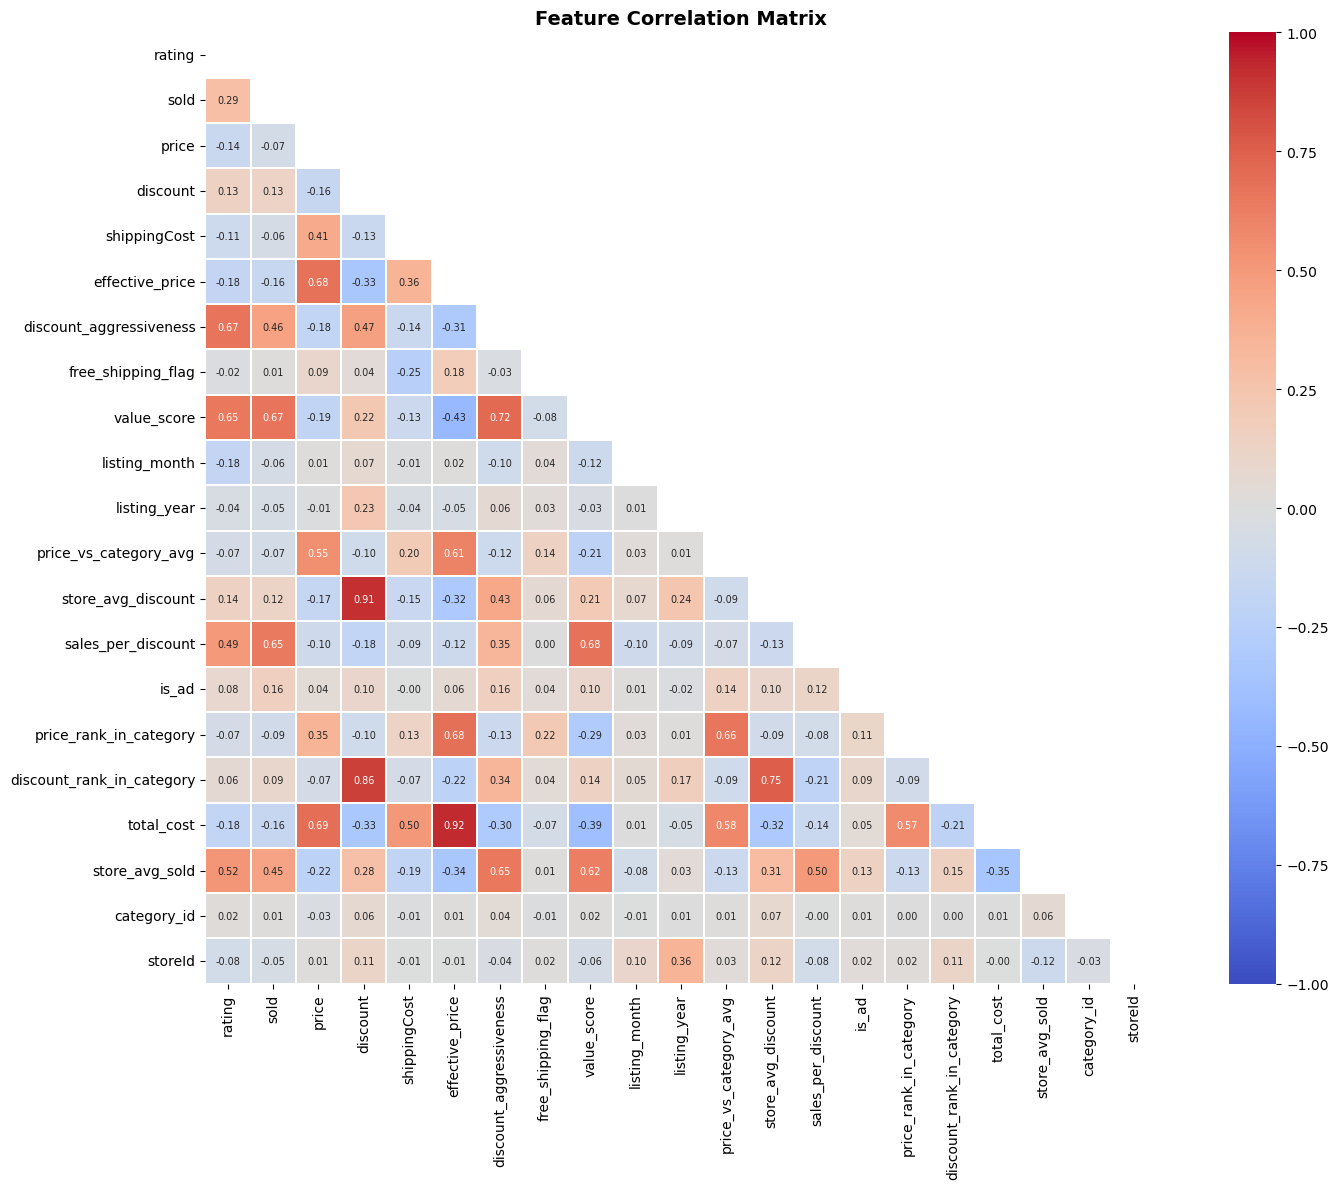

In [4]:
plt.figure(figsize=(16, 12))

# Step 1: Compute the Pearson correlation matrix
# .corr() calculates pairwise correlation between every pair of columns
# Output: a symmetric N×N matrix where diagonal = 1.0 (every feature
# perfectly correlates with itself)
corr_matrix = df[features].corr()

# Step 2: Build an upper-triangle mask
# np.triu returns a matrix of True/False where True = upper triangle
# np.ones_like creates a matrix of 1s with the same shape as corr_matrix
# dtype=bool casts those 1s to True
# WHY: the correlation matrix is symmetric — upper and lower triangles
# are mirror images. Masking the upper half removes duplicates and
# makes the heatmap easier to read.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot     = True,        # print the r value inside each cell
    fmt       = '.2f',       # round to 2 decimal places (e.g. 0.87)
    cmap      = 'coolwarm',  # blue = negative corr, red = positive corr
    mask      = mask,        # hide upper triangle (show lower only)
    square    = True,        # force square cells — easier to scan diagonally
    linewidths= 0.3,         # thin grid lines to separate cells visually
    annot_kws = {'size': 7}, # smaller font so numbers don't overlap
    vmin=-1, vmax=1          # fix color scale to full [-1, +1] range
)

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Correlation Analysis 

###  High Correlations Detected (> 0.85)

| Feature A | Feature B | Correlation | Action |
|---|---|---|---|
| `store_avg_discount` | `discount` | **0.91** | Drop `store_avg_discount` |
| `discount_rank_in_category` | `discount` | **0.86** | Drop `discount_rank_in_category` |
| `total_cost` | `effective_price` | **0.92** | Drop `total_cost` |
| `total_cost` | `price` | **0.92** | Already dropping `total_cost` |



In [5]:
# Drop highly correlated features 
to_drop_corr = [
    'store_avg_discount',        # 0.91 correlated with discount
    'discount_rank_in_category', # 0.86 correlated with discount  
    'total_cost',                # 0.92 correlated with effective_price
]

df = df.drop(columns=to_drop_corr, errors='ignore')
print("done")
print(f"  still here       : {df.columns.tolist()}")

done
  still here       : ['storeId', 'rating', 'sold', 'price', 'discount', 'shippingCost', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'free_shipping_flag', 'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg', 'sales_per_discount', 'is_ad', 'price_rank_in_category', 'store_avg_sold']


# Mutual Information Scores
 Mutual Information (MI) measures how much a feature helps predict the target variable (sold)
 ( sold : target cause we want to find which pricing strategy drives most sales )
 
 MI = 0   → feature is useless for predicting sold
 MI > 0   → feature carries useful information
 Higher MI = more important feature



In [8]:
from sklearn.feature_selection import mutual_info_regression
target = 'sold'
X = df.drop(columns=[
    target,
    'category_name',  # string column
    'type',           # replaced by is_ad
    'storeId',        # high cardinality ID
], errors='ignore').select_dtypes(include=['number'])

y = df[target]

# Fill any remaining NaN 
X = X.fillna(X.median(numeric_only=True))

print(f"Features going into MI: {X.columns.tolist()}")
print(f"  Total : {X.shape[1]} features")

# Compute MI scores

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature'  : X.columns,
    'MI_Score' : mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nMutual Information Scores (higher = more useful):")

print(mi_df.to_string(index=False))

Features going into MI: ['rating', 'price', 'discount', 'shippingCost', 'category_id', 'effective_price', 'discount_aggressiveness', 'free_shipping_flag', 'value_score', 'listing_month', 'listing_year', 'price_vs_category_avg', 'sales_per_discount', 'is_ad', 'price_rank_in_category', 'store_avg_sold']
  Total : 16 features

Mutual Information Scores (higher = more useful):
                Feature  MI_Score
     sales_per_discount  2.845428
discount_aggressiveness  2.182213
            value_score  0.815782
         store_avg_sold  0.580042
                 rating  0.536252
        effective_price  0.139991
            category_id  0.120258
                  price  0.104848
  price_vs_category_avg  0.082831
 price_rank_in_category  0.075360
           shippingCost  0.072826
               discount  0.038762
          listing_month  0.021424
           listing_year  0.014128
                  is_ad  0.013540
     free_shipping_flag  0.000140


# Interpretation :  Strong features (MI > 0.1) >keep :

| Feature | MI Score | Strength |
|---|---|---|
| `sales_per_discount` | **2.84** |  Very Strong |
| `discount_aggressiveness` | **2.18** |  Very Strong |
| `value_score` | **0.82** |  Strong |
| `store_avg_sold` | **0.58** |  Strong |
| `rating` | **0.54** |  Strong |
| `effective_price` | **0.14** |  Moderate |
| `category_id` | **0.12** |  Moderate |
| `price` | **0.10** |  Moderate |
| `price_vs_category_avg` | **0.08** |  Borderline |
| `price_rank_in_category` | **0.08** |  Borderline |
| `shippingCost` | **0.07** |  Borderline |
| `discount` | **0.04** |  Weak |
| `listing_month` | **0.02** |  Weak |
| `listing_year` | **0.01** |  Weak |
| `is_ad` | **0.01** |  Weak |
| `free_shipping_flag` | **0.00** |  Negligible |

### Weak Features — Drop (MI < 0.05)

| Feature | MI Score | 
|---|---|
| `discount` | **0.04** | 
| `listing_month` | **0.02** | 
| `listing_year` | **0.01** | 
| `is_ad` | **0.01** | 
| `free_shipping_flag` | **0.00** | 

In [9]:
# Drop features with MI score below threshold
weak_features = [
    'free_shipping_flag',  
    'listing_year',        
    'is_ad',              
    'listing_month',       
    'discount',            
]
df = df.drop(columns=weak_features, errors='ignore')
print(f" Dropped {len(weak_features)} weak features")
print(f"\n  Final features ({df.select_dtypes(include='number').shape[1]}):")
for col in df.select_dtypes(include='number').columns:
    print(f"  → {col}")
# Save final dataset
df.to_csv('df_final.csv', index=False)
print(f"\n  ready for clustering!")
print(f"  Shape : {df.shape}")

 Dropped 5 weak features

  Final features (13):
  → storeId
  → rating
  → sold
  → price
  → shippingCost
  → category_id
  → effective_price
  → discount_aggressiveness
  → value_score
  → price_vs_category_avg
  → sales_per_discount
  → price_rank_in_category
  → store_avg_sold

  ready for clustering!
  Shape : (711168, 15)
